In [2]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import umap
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score


In [3]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

Load data set

In [4]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'..\\data\\data_temp\\cacao.csv')
df_algarrobo = pd.read_csv(r'..\\data\\data_temp\\algarrobo.csv')

df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]
X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

C:\Users\salvador.romomacias\AppData\Local\Temp\ipykernel_13444\3369564250.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])


In [5]:
def ICAFS(datasetX, datasetY, strenght,max_iteartion,model):
  max_iteartion_aux =  max_iteartion
  t_strenght = strenght
  v_variable = [0, 1]
  best_f1_score = float('-inf')
  best_data_set = datasetX.columns.values.copy()
  max_iteration = 60
  max_len = inf
  score_list = []
  featur_list = []
  iter_list = []
  max_it = 1;

  initialTestTraining(score_list,iter_list,featur_list,datasetX,datasetY,model)
  while (max_iteartion_aux >= 0):

      dict_parameters = {}
      partial_best_list = []
      partial_score = 0
      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      random.shuffle(best_data_set)
      generate_covering_array = Covering(dict_parameters, strength=t_strenght)
      for test in generate_covering_array.array:
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          df_temp = datasetX.loc[ :,list_attributes_to_consider]
          X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(df_temp.values, datasetY.values.ravel(), test_size=0.20,
                                                                                  random_state=42)
          clf_new = train_model(model)
          clf_new.fit(X_train_temp, y_train_temp)

          y_pred = clf_new.predict(X_test_temp)
          print(list_attributes_to_consider)
          score = f1_score(y_test_temp, y_pred,average='macro')
          #print(score)
          if score > partial_score :
              partial_score = score
              partial_best_list = list_attributes_to_consider
          clf_new = None
      best_data_set = partial_best_list.copy()
      best_f1_score = partial_score
      print("best_f1_score= %s" % best_f1_score)
      print(best_data_set)
      print(len(best_data_set))
      print('---------------------')

      aux_data_score = best_f1_score
      score_list.append(aux_data_score)
      max_iteartion_aux = max_iteartion_aux-1
      max_it = max_it +1
      featur_list.append(len(best_data_set))
      iter_list.append(max_it)
  return iter_list,featur_list,score_list

def initialTestTraining(score_list, iter_list, feature_list ,X,y,model):
     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X.values, y.values.ravel(), test_size=0.20, random_state=42)
     clf_new = train_model(model)
     clf_new.fit(X_train_temp, y_train_temp)
     y_pred = clf_new.predict(X_test_temp)
     score_list.append(f1_score(y_test_temp, y_pred,average='macro'))
     feature_list.append(X.shape[1])
     iter_list.append(0)

def train_model(model_name='ComplementNB'):  
    m = eval(model_name)
    return m

In [6]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        #for i in range(len(res_iter)):
        #    ax1.text(i+1-0.2,    res_features[i], res_features[i],rotation='vertical')
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        #for i in range(len(res_iter)):
        #    ax2.text(i+1, res_scores[i], f"{res_scores[i]:.3f}",rotation='vertical')

        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

ICAFS KNN

['1102', '1103', '1104', '1105', '1106', '1107', '1108', '1109', '1110', '1111', '1112', '1113', '1114', '1115', '1116', '1117', '1118', '1119', '1120', '1121', '1122', '1123', '1124', '1125', '1126', '1127', '1128', '1129', '1130', '1131', '1132', '1133', '1134', '1135', '1136', '1137', '1138', '1139', '1140', '1141', '1142', '1143', '1144', '1145', '1146', '1147', '1148', '1149', '1150', '1151', '1152', '1153', '1154', '1155', '1156', '1157', '1158', '1159', '1160', '1161', '1162', '1163', '1164', '1165', '1166', '1167', '1168', '1169', '1170', '1171', '1172', '1173', '1174', '1175', '1176', '1177', '1178', '1179', '1180', '1181', '1182', '1183', '1184', '1185', '1186', '1187', '1188', '1189', '1190', '1191', '1192', '1193', '1194', '1195', '1196', '1197', '1198', '1199', '1200', '1201', '1202', '1203', '1204', '1205', '1206', '1207', '1208', '1209', '1210', '1211', '1212', '1213', '1214', '1215', '1216', '1217', '1218', '1219', '1220', '1221', '1222', '1223', '1224', '1225', '1226',

<Figure size 1100x1000 with 0 Axes>

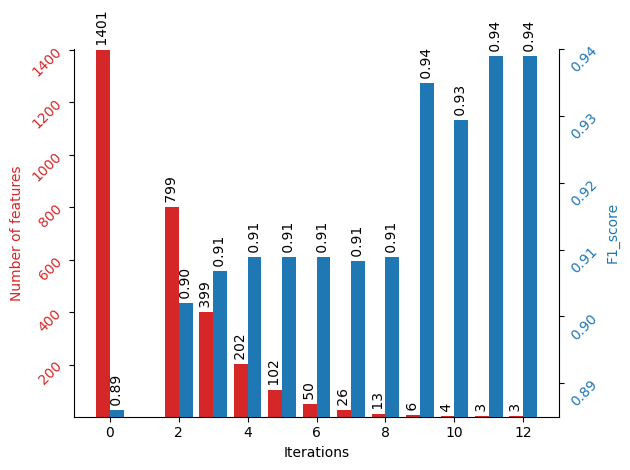

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cacao,y_cacao,2,10,'KNeighborsClassifier(n_neighbors=3)')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_knn_icafs.png')

5 Fold Validation ICAFS KNN

In [7]:
clf = KNeighborsClassifier(n_neighbors=3)
X = X_cacao[['1736', '1993', '2089']]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao nibs mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )


5-CV Cacao nibs mean:0.897521551813014 , 5-CV Cacao STD:0.06379850690808213


['B', 'Edge Red', 'NIR', 'EXG', 'EXGR', 'NGRDI', 'NGBDI', 'RGRI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'DVI', 'EVI', 'REVI', 'NDRE', 'RERVI', 'REDVI']
['G']
['R', 'Edge Red', 'EXG', 'NGRDI', 'RGRI', 'GBRI.1', 'VEG', 'MGRVI', 'RVI', 'EVI', 'NDRE', 'REDVI']
['R', 'G', 'B', 'NIR', 'EXGR', 'NGBDI', 'GBRI', 'CIVE', 'RGBVI', 'NDVI', 'DVI', 'REVI', 'RERVI']
['NIR', 'EXG', 'EXGR', 'RGRI', 'GBRI', 'VEG', 'RGBVI', 'RVI', 'DVI', 'NDRE', 'RERVI']
['G', 'Edge Red', 'NIR', 'EXG', 'NGRDI', 'NGBDI', 'GBRI.1', 'CIVE', 'MGRVI', 'NDVI', 'EVI', 'REVI', 'REDVI']
['B', 'EXGR', 'NGRDI', 'NGBDI', 'RGRI', 'GBRI.1', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'RERVI', 'REDVI']
['Edge Red', 'EXGR', 'NGBDI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'DVI', 'EVI', 'REVI', 'NDRE']
['B', 'NGRDI', 'RGRI', 'GBRI', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'DVI', 'EVI', 'REVI']
['G', 'RGRI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'EVI', 'NDRE', 'RERVI', 'REDVI']
['Edge Red', 'CIVE', '

<Figure size 1100x1000 with 0 Axes>

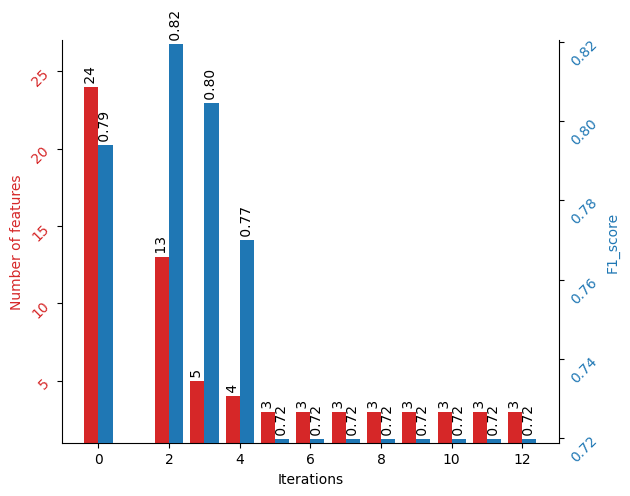

In [8]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'KNeighborsClassifier(n_neighbors=3)')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_knn_icafs.png')

5 Cross Validation KNN Algarrobo

In [8]:
clf = KNeighborsClassifier(n_neighbors=3)
X = X_algarrobo[['NGRDI', 'NGBDI', 'GBRI.1', 'NDVI', 'EVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV algarrobo mean:{res.mean()} , 5-CV algarrobo STD:{res.std()}" )

5-CV algarrobo mean:0.6979561046789613 , 5-CV algarrobo STD:0.0707038091614825


['Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']
['X10']
['Y', 'X20', 'X30', 'X40']
['Y', 'X10', 'Y10', 'Y20', 'Y30', 'Y40']
['X', 'Y20', 'X30', 'Y40']
['X', 'X10', 'Y10', 'X20', 'Y30', 'X40']
['X', 'Y', 'Y10', 'X30', 'Y30']
['X', 'Y', 'X10', 'X20', 'Y20', 'X40', 'Y40']
['Y10', 'X40', 'Y40']
['X10', 'X20', 'Y20', 'X30', 'Y30']
['X', 'Y', 'Y10', 'X20', 'Y20']
['X', 'Y', 'X10', 'X30', 'Y30', 'X40', 'Y40']
['X10', 'Y10', 'X30', 'X40']
['X20', 'Y20', 'Y30', 'X40']
['X', 'Y', 'X40', 'Y40']
['X', 'Y', 'X20', 'Y20', 'X30', 'Y30', 'Y40']
['Y30', 'Y40']
['X20', 'Y20', 'X40', 'Y40']
['X', 'X10', 'Y10', 'X20', 'Y40']
['Y', 'Y10', 'Y20', 'X40']
['X', 'Y', 'X10']
best_f1_score= 0.9809972636059592
['X', 'Y', 'X10']
3
---------------------
['X10']
['Y']
['Y', 'X10']
['X']
['X', 'X10']
['X', 'Y']
['X', 'Y', 'X10']
best_f1_score= 0.9914973960775487
['X', 'Y']
2
---------------------
['Y']
['X']
['X', 'Y']
best_f1_score= 0.9914973960775487
['X', 'Y']
2
---------------------
['Y']
['X']
['X', 'Y']
best_

<Figure size 1100x1000 with 0 Axes>

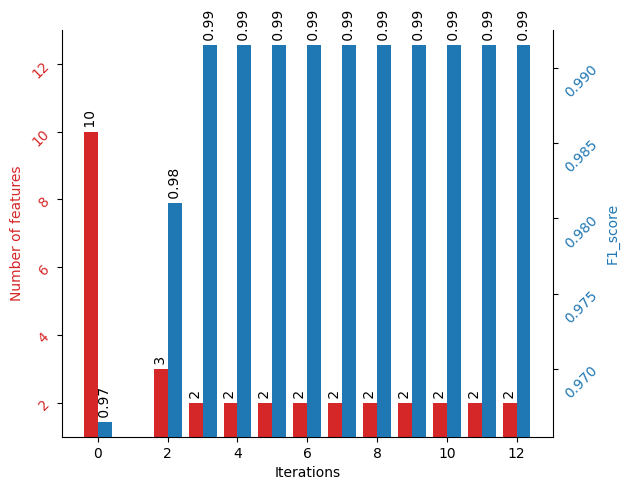

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'KNeighborsClassifier(n_neighbors=3)')
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

5 Cross Validation CIS

In [11]:
clf = KNeighborsClassifier(n_neighbors=3)
X = X_cis[['X', 'Y']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

5-CV CIS mean:0.9862988696637448 , 5-CV CIS STD:0.0009278667797298965


ICAFS OPF

2025-03-06 22:32:46,768 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-06 22:32:46,770 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-06 22:32:46,772 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-06 22:32:46,773 - opfython.core.opf — INFO — Class created.
2025-03-06 22:32:46,774 - opfython.models.supervised — INFO — Class overrided.
2025-03-06 22:32:46,775 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-06 22:32:46,782 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-06 22:32:47,448 - opfython.models.supervised — DEBUG — Prototypes: [638, 406, 206, 164, 596, 464, 188, 265, 504, 521, 195, 729, 320, 149, 395, 28, 261, 38, 256, 266, 632, 69, 359, 517, 51, 170, 644, 444, 426, 383, 696, 686, 693, 567, 424, 319, 397, 507, 85, 510, 654, 461, 791, 668, 289, 416, 605, 641, 457, 664, 280, 427, 283, 617, 220, 4, 75, 328, 749, 59, 401, 734, 493, 481, 3

<Figure size 1100x1000 with 0 Axes>

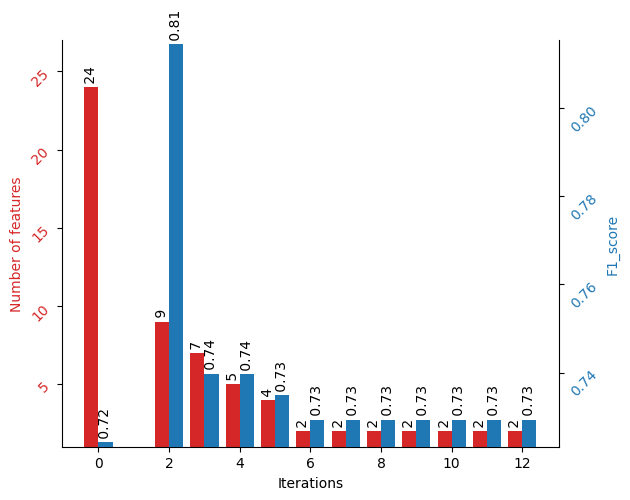

In [100]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_opf_icafs.png')

2025-03-06 22:35:39,228 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-06 22:35:39,229 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-06 22:35:39,230 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-06 22:35:39,232 - opfython.core.opf — INFO — Class created.
2025-03-06 22:35:39,233 - opfython.models.supervised — INFO — Class overrided.


2025-03-06 22:35:39,234 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-06 22:35:39,242 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-06 22:35:41,421 - opfython.models.supervised — DEBUG — Prototypes: [225, 287, 653, 313, 761, 740, 366, 262, 145, 25, 285, 752, 178, 578, 515, 182, 695, 549, 123, 563, 341, 647, 325, 597, 167, 632, 37, 408, 711, 63, 45, 656, 658, 121, 163, 521, 421, 388, 109, 363, 713, 791, 483, 668, 395, 208, 156, 72, 558, 725, 398, 719, 619, 65, 299, 750, 70, 250, 426, 256, 43, 3, 624, 358, 193, 270, 599, 626, 679, 572, 405, 120, 762, 657, 705, 253, 783, 261, 90, 75, 251, 244, 326, 516, 126, 131, 491, 707, 602, 779, 663, 523, 141, 165, 414, 374, 757, 526, 776, 127, 722, 48, 356, 323, 188, 331, 385, 294, 782, 355, 737, 670, 404, 24, 272, 410, 80, 540, 241, 786, 368, 784, 57, 511, 771, 181, 17, 754, 290, 764, 170, 322, 455, 559, 644, 306, 464, 770, 185, 86, 396, 721, 654, 566, 315, 284, 309, 399, 144, 142, 473, 731, 362, 633, 6

<Figure size 1100x1000 with 0 Axes>

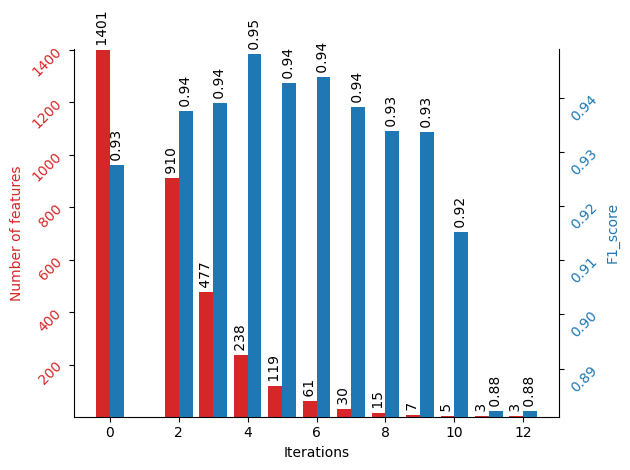

In [101]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)' )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_opf_icafs.png')

In [22]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,2,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cis_opf_icafs.png')

2025-03-08 11:40:13,771 - opfython.models.supervised — INFO — Overriding class: OPF -> SupervisedOPF.
2025-03-08 11:40:13,772 - opfython.core.opf — INFO — Creating class: OPF.
2025-03-08 11:40:13,773 - opfython.core.opf — DEBUG — Distance: log_squared_euclidean | Pre-computed distance: False.
2025-03-08 11:40:13,774 - opfython.core.opf — INFO — Class created.
2025-03-08 11:40:13,775 - opfython.models.supervised — INFO — Class overrided.
2025-03-08 11:40:13,776 - opfython.models.supervised — INFO — Fitting classifier ...
2025-03-08 11:40:13,808 - opfython.models.supervised — DEBUG — Finding prototypes ...
2025-03-08 11:40:39,497 - opfython.models.supervised — DEBUG — Prototypes: [199, 447, 4439, 743, 3024, 925, 5082, 3317, 3435, 7027, 1606, 1084, 5634, 3235, 1628, 5012, 7937, 422, 4560, 5781, 4329, 3637, 6881, 5426, 4785, 2674, 6732, 3847, 2064, 806, 5611, 2261, 4038, 3258, 4900, 4060, 6505, 3880, 4187, 2566, 136, 994, 3487, 7479, 6929, 794, 168, 297, 1966, 3035, 3663, 3675, 5829, 1927,

KeyboardInterrupt: 

ICAFS SVC

['1102', '1103', '1104', '1105', '1106', '1107', '1108', '1109', '1110', '1111', '1112', '1113', '1114', '1115', '1116', '1117', '1118', '1119', '1120', '1121', '1122', '1123', '1124', '1125', '1126', '1127', '1128', '1129', '1130', '1131', '1132', '1133', '1134', '1135', '1136', '1137', '1138', '1139', '1140', '1141', '1142', '1143', '1144', '1145', '1146', '1147', '1148', '1149', '1150', '1151', '1152', '1153', '1154', '1155', '1156', '1157', '1158', '1159', '1160', '1161', '1162', '1163', '1164', '1165', '1166', '1167', '1168', '1169', '1170', '1171', '1172', '1173', '1174', '1175', '1176', '1177', '1178', '1179', '1180', '1181', '1182', '1183', '1184', '1185', '1186', '1187', '1188', '1189', '1190', '1191', '1192', '1193', '1194', '1195', '1196', '1197', '1198', '1199', '1200', '1201', '1202', '1203', '1204', '1205', '1206', '1207', '1208', '1209', '1210', '1211', '1212', '1213', '1214', '1215', '1216', '1217', '1218', '1219', '1220', '1221', '1222', '1223', '1224', '1225', '1226',

<Figure size 1100x1000 with 0 Axes>

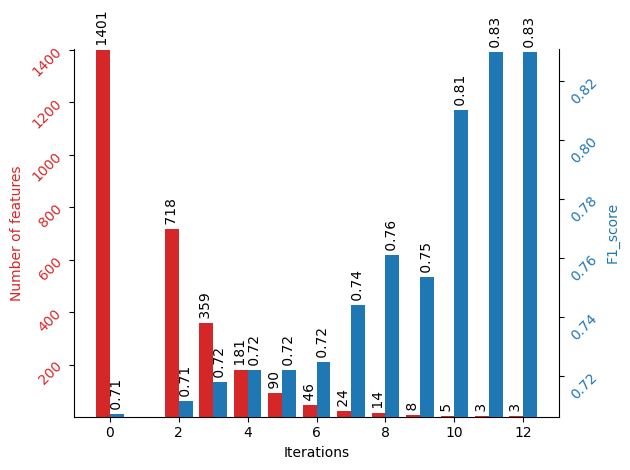

In [103]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'svm.SVC()' )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_svc_icafs.png')

5 Cross SVC ICAFS Cacao

In [15]:
clf = svm.SVC()
X = X_cacao[['1734', '1926', '2310']]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

5-CV Cacao mean:0.8230015663113133 , 5-CV Cacao STD:0.07054212671304273


['B', 'Edge Red', 'NIR', 'EXG', 'EXGR', 'NGRDI', 'NGBDI', 'RGRI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'DVI', 'EVI', 'REVI', 'NDRE', 'RERVI', 'REDVI']
['G']
['R', 'Edge Red', 'EXG', 'NGRDI', 'RGRI', 'GBRI.1', 'VEG', 'MGRVI', 'RVI', 'EVI', 'NDRE', 'REDVI']
['R', 'G', 'B', 'NIR', 'EXGR', 'NGBDI', 'GBRI', 'CIVE', 'RGBVI', 'NDVI', 'DVI', 'REVI', 'RERVI']
['NIR', 'EXG', 'EXGR', 'RGRI', 'GBRI', 'VEG', 'RGBVI', 'RVI', 'DVI', 'NDRE', 'RERVI']
['G', 'Edge Red', 'NIR', 'EXG', 'NGRDI', 'NGBDI', 'GBRI.1', 'CIVE', 'MGRVI', 'NDVI', 'EVI', 'REVI', 'REDVI']
['B', 'EXGR', 'NGRDI', 'NGBDI', 'RGRI', 'GBRI.1', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'RERVI', 'REDVI']
['Edge Red', 'EXGR', 'NGBDI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'DVI', 'EVI', 'REVI', 'NDRE']
['B', 'NGRDI', 'RGRI', 'GBRI', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'DVI', 'EVI', 'REVI']
['G', 'RGRI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'EVI', 'NDRE', 'RERVI', 'REDVI']
['Edge Red', 'CIVE', '

<Figure size 1100x1000 with 0 Axes>

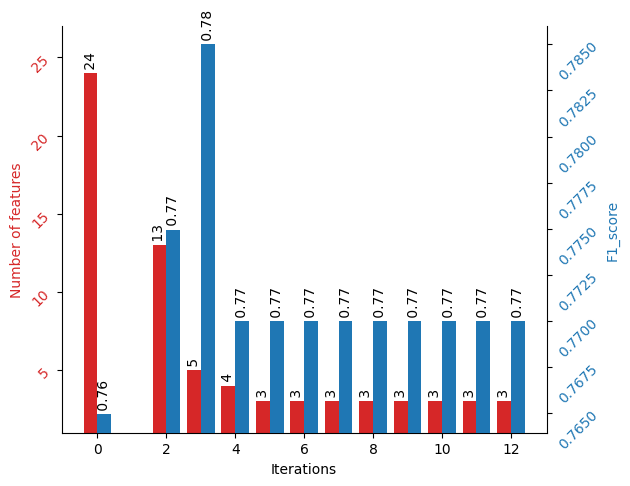

In [104]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'svm.SVC()' )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_svc_icafs.png')

ICAFS KNN SVC Algarrobo

In [16]:
clf = svm.SVC()
X = X_algarrobo[['NIR', 'CIVE', 'NDVI', 'EVI', 'REDVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo mean:{res.mean()} , 5-CV ALgarrobo STD:{res.std()}" )

5-CV Algarrobo mean:0.7482284534699325 , 5-CV ALgarrobo STD:0.03362987294329091


['Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']
['X10']
['Y', 'X20', 'X30', 'X40']
['Y', 'X10', 'Y10', 'Y20', 'Y30', 'Y40']
['X', 'Y20', 'X30', 'Y40']
['X', 'X10', 'Y10', 'X20', 'Y30', 'X40']
['X', 'Y', 'Y10', 'X30', 'Y30']
['X', 'Y', 'X10', 'X20', 'Y20', 'X40', 'Y40']
['Y10', 'X40', 'Y40']
['X10', 'X20', 'Y20', 'X30', 'Y30']
['X', 'Y', 'Y10', 'X20', 'Y20']
['X', 'Y', 'X10', 'X30', 'Y30', 'X40', 'Y40']
['X10', 'Y10', 'X30', 'X40']
['X20', 'Y20', 'Y30', 'X40']
['X', 'Y', 'X40', 'Y40']
['X', 'Y', 'X20', 'Y20', 'X30', 'Y30', 'Y40']
['Y30', 'Y40']
['X20', 'Y20', 'X40', 'Y40']
['X', 'X10', 'Y10', 'X20', 'Y40']
['Y', 'Y10', 'Y20', 'X40']
['X', 'Y', 'X10']
best_f1_score= 0.9804999561249013
['X', 'Y', 'X40', 'Y40']
4
---------------------
['Y40']
['X40']
['Y']
['Y', 'X40', 'Y40']
['X']
['X', 'X40', 'Y40']
['X', 'Y', 'Y40']
['X', 'Y', 'X40']
best_f1_score= 0.9834996658682338
['X', 'Y', 'Y40']
3
---------------------
['Y40']
['Y']
['Y', 'Y40']
['X']
['X', 'Y40']
['X', 'Y']
['X', 'Y', 'Y40']
be

<Figure size 1100x1000 with 0 Axes>

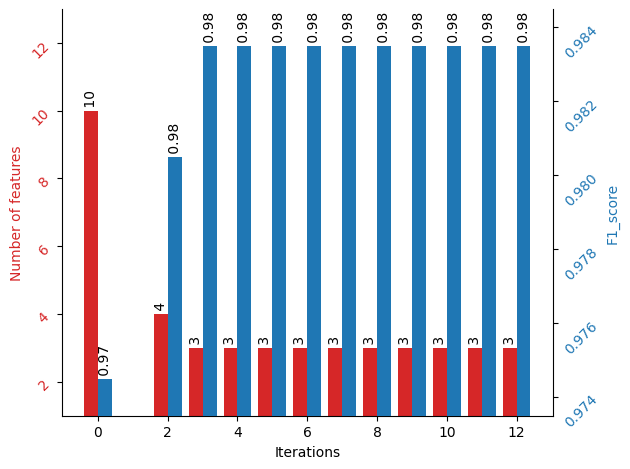

In [105]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'svm.SVC()')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

5 Cross Validation ICAFS CIS SVC

In [17]:
clf = svm.SVC()
X = X_cis[['X', 'Y', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

5-CV CIS mean:0.9776880241490421 , 5-CV CIS STD:0.0036194375244417236


ICAFS MLP

['1102', '1103', '1104', '1105', '1106', '1107', '1108', '1109', '1110', '1111', '1112', '1113', '1114', '1115', '1116', '1117', '1118', '1119', '1120', '1121', '1122', '1123', '1124', '1125', '1126', '1127', '1128', '1129', '1130', '1131', '1132', '1133', '1134', '1135', '1136', '1137', '1138', '1139', '1140', '1141', '1142', '1143', '1144', '1145', '1146', '1147', '1148', '1149', '1150', '1151', '1152', '1153', '1154', '1155', '1156', '1157', '1158', '1159', '1160', '1161', '1162', '1163', '1164', '1165', '1166', '1167', '1168', '1169', '1170', '1171', '1172', '1173', '1174', '1175', '1176', '1177', '1178', '1179', '1180', '1181', '1182', '1183', '1184', '1185', '1186', '1187', '1188', '1189', '1190', '1191', '1192', '1193', '1194', '1195', '1196', '1197', '1198', '1199', '1200', '1201', '1202', '1203', '1204', '1205', '1206', '1207', '1208', '1209', '1210', '1211', '1212', '1213', '1214', '1215', '1216', '1217', '1218', '1219', '1220', '1221', '1222', '1223', '1224', '1225', '1226',

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


['1226', '1235', '1240', '1242', '1245', '1247', '1257', '1260', '1272', '1276', '1290', '1319', '1325', '1329', '1341', '1347', '1350', '1356', '1362', '1371', '1373', '1376', '1419', '1431', '1441', '1454', '1460', '1481', '1485', '1489', '1502', '1514', '1529', '1532', '1551', '1571', '1573', '1598', '1616', '1631', '1644', '1675', '1696', '1713', '1715', '1718', '1742', '1753', '1757', '1768', '1788', '1825', '1827', '1830', '1859', '1883', '1898', '1912', '1943', '1968', '1970', '1973', '1997', '2009', '2013', '2024', '2044', '2082', '2084', '2093', '2118', '2142', '2168', '2172', '2213', '2237', '2240', '2243', '2267', '2281', '2296', '2337', '2353', '2394', '2396', '2399', '2469']
['1226', '1232', '1234', '1239', '1241', '1243', '1246', '1255', '1259', '1271', '1275', '1279', '1318', '1321', '1328', '1330', '1346', '1349', '1353', '1357', '1370', '1372', '1375', '1379', '1430', '1440', '1453', '1455', '1478', '1484', '1488', '1490', '1513', '1515', '1531', '1535', '1570', '1572'

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


['1239', '1240', '1241', '1245', '1246', '1257', '1259', '1272', '1275', '1290', '1318', '1325', '1328', '1341', '1346', '1350', '1353', '1362', '1370', '1373', '1375', '1419', '1430', '1441', '1453', '1460', '1478', '1485', '1488', '1502', '1513', '1529', '1531', '1551', '1570', '1573', '1597', '1616', '1627', '1644', '1656', '1696', '1712', '1715', '1717', '1742', '1748', '1757', '1767', '1788', '1802', '1827', '1829', '1859', '1882', '1898', '1911', '1943', '1967', '1970', '1972', '1997', '2004', '2013', '2023', '2044', '2058', '2084', '2086', '2118', '2141', '2168', '2171', '2213', '2229', '2240', '2242', '2267', '2279', '2296', '2323', '2353', '2357', '2396', '2398', '2469']
['1232', '1235', '1239', '1240', '1242', '1243', '1247', '1255', '1260', '1271', '1276', '1279', '1319', '1321', '1329', '1330', '1347', '1349', '1356', '1357', '1371', '1372', '1376', '1379', '1431', '1440', '1454', '1455', '1481', '1484', '1489', '1490', '1514', '1515', '1532', '1535', '1571', '1572', '1598'

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


['1234', '1242', '1245', '1246', '1255', '1257', '1259', '1260', '1271', '1275', '1276', '1279', '1325', '1329', '1341', '1346', '1347', '1349', '1353', '1356', '1357', '1373', '1419', '1430', '1431', '1440', '1453', '1454', '1455', '1485', '1502', '1513', '1514', '1515', '1531', '1532', '1535', '1573', '1616', '1627', '1631', '1642', '1656', '1675', '1679', '1715', '1742', '1748', '1753', '1756', '1767', '1768', '1769', '1827', '1859', '1882', '1883', '1887', '1911', '1912', '1931', '1970', '1997', '2004', '2009', '2012', '2023', '2024', '2025', '2084', '2118', '2141', '2142', '2153', '2171', '2172', '2198', '2240', '2267', '2279', '2281', '2284', '2323', '2337', '2338', '2396', '2469']
['1232', '1245', '1246', '1247', '1255', '1257', '1259', '1260', '1271', '1272', '1276', '1290', '1318', '1319', '1321', '1328', '1330', '1350', '1356', '1362', '1370', '1371', '1372', '1375', '1376', '1379', '1441', '1460', '1478', '1481', '1484', '1488', '1489', '1490', '1529', '1551', '1570', '1571'

<Figure size 1100x1000 with 0 Axes>

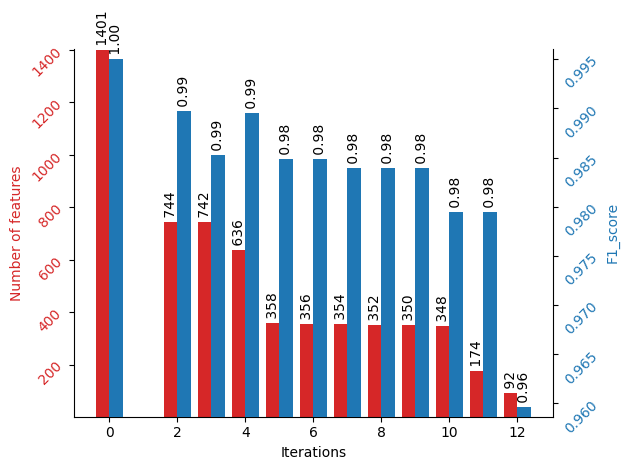

In [108]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)' )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_mlp_icafs.png')

ICAFS MLP CACAO 5 CV

In [18]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cacao[['1235', '1255', '1257', '1259', '1260', '1271', '1272', '1275', '1279', '1290', '1318', '1319', '1321', '1325', '1328', '1329', '1330', '1341', '1346', '1347', '1349', '1350', '1353', '1371', '1373', '1375', '1376', '1431', '1454', '1455', '1460', '1478', '1484', '1489', '1490', '1502', '1513', '1515', '1529', '1531', '1571', '1573', '1597', '1598', '1631', '1675', '1679', '1696', '1712', '1714', '1733', '1742', '1748', '1756', '1757', '1767', '1825', '1827', '1829', '1830', '1883', '1912', '1931', '1943', '1967', '1969', '1974', '1997', '2004', '2012', '2013', '2023', '2082', '2084', '2086', '2093', '2142', '2172', '2198', '2213', '2229', '2238', '2245', '2267', '2279', '2284', '2296', '2323', '2394', '2396', '2398', '2399']
]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

c:\Users\salvador.romomacias\AppData\Local\miniconda3\envs\icafs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


5-CV Cacao mean:0.9416941064402387 , 5-CV Cacao STD:0.040216180247237124


['B', 'Edge Red', 'NIR', 'EXG', 'EXGR', 'NGRDI', 'NGBDI', 'RGRI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'DVI', 'EVI', 'REVI', 'NDRE', 'RERVI', 'REDVI']
['G']
['R', 'Edge Red', 'EXG', 'NGRDI', 'RGRI', 'GBRI.1', 'VEG', 'MGRVI', 'RVI', 'EVI', 'NDRE', 'REDVI']
['R', 'G', 'B', 'NIR', 'EXGR', 'NGBDI', 'GBRI', 'CIVE', 'RGBVI', 'NDVI', 'DVI', 'REVI', 'RERVI']
['NIR', 'EXG', 'EXGR', 'RGRI', 'GBRI', 'VEG', 'RGBVI', 'RVI', 'DVI', 'NDRE', 'RERVI']
['G', 'Edge Red', 'NIR', 'EXG', 'NGRDI', 'NGBDI', 'GBRI.1', 'CIVE', 'MGRVI', 'NDVI', 'EVI', 'REVI', 'REDVI']
['B', 'EXGR', 'NGRDI', 'NGBDI', 'RGRI', 'GBRI.1', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'RERVI', 'REDVI']
['Edge Red', 'EXGR', 'NGBDI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'DVI', 'EVI', 'REVI', 'NDRE']
['B', 'NGRDI', 'RGRI', 'GBRI', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'DVI', 'EVI', 'REVI']
['G', 'RGRI', 'GBRI', 'GBRI.1', 'CIVE', 'VEG', 'RGBVI', 'MGRVI', 'NDVI', 'RVI', 'EVI', 'NDRE', 'RERVI', 'REDVI']
['Edge Red', 'CIVE', '

<Figure size 1100x1000 with 0 Axes>

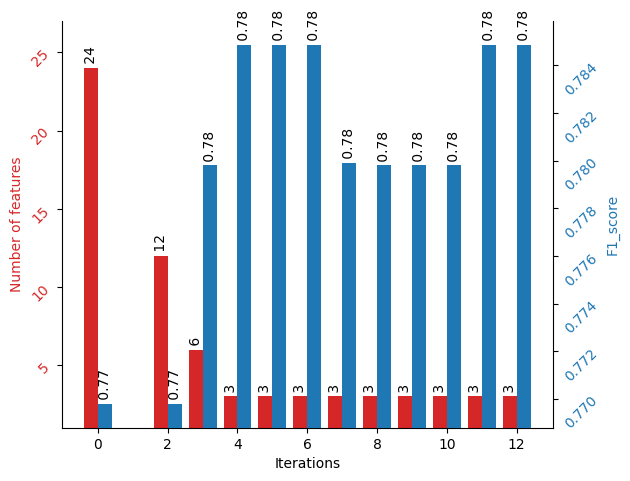

In [109]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)' )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_mlp_icafs.png')

ICAFS MLP Algarrobo 5 CV

In [19]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_algarrobo[['R', 'MGRVI', 'REDVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

5-CV Algarrobo mean:0.7333539892219313 , 5-CV Algarrobo STD:0.047161175129456806


['Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']
['X10']
['Y', 'X20', 'X30', 'X40']
['Y', 'X10', 'Y10', 'Y20', 'Y30', 'Y40']
['X', 'Y20', 'X30', 'Y40']
['X', 'X10', 'Y10', 'X20', 'Y30', 'X40']
['X', 'Y', 'Y10', 'X30', 'Y30']
['X', 'Y', 'X10', 'X20', 'Y20', 'X40', 'Y40']
['Y10', 'X40', 'Y40']
['X10', 'X20', 'Y20', 'X30', 'Y30']
['X', 'Y', 'Y10', 'X20', 'Y20']
['X', 'Y', 'X10', 'X30', 'Y30', 'X40', 'Y40']
['X10', 'Y10', 'X30', 'X40']
['X20', 'Y20', 'Y30', 'X40']
['X', 'Y', 'X40', 'Y40']
['X', 'Y', 'X20', 'Y20', 'X30', 'Y30', 'Y40']
['Y30', 'Y40']
['X20', 'Y20', 'X40', 'Y40']
['X', 'X10', 'Y10', 'X20', 'Y40']
['Y', 'Y10', 'Y20', 'X40']
['X', 'Y', 'X10']
best_f1_score= 0.958999835999344
['X', 'Y', 'X40', 'Y40']
4
---------------------
['Y40']
['X40']
['Y']
['Y', 'X40', 'Y40']
['X']
['X', 'X40', 'Y40']
['X', 'Y', 'Y40']
['X', 'Y', 'X40']
best_f1_score= 0.95999963999676
['X', 'Y', 'Y40']
3
---------------------
['Y40']
['Y']
['Y', 'Y40']
['X']
['X', 'Y40']
['X', 'Y']
['X', 'Y', 'Y40']
best_

<Figure size 1100x1000 with 0 Axes>

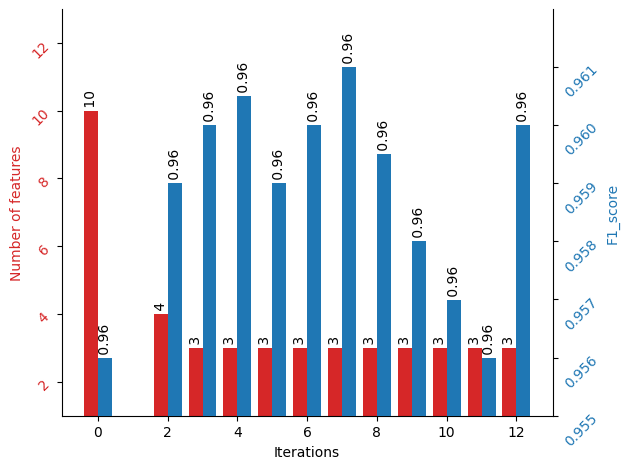

In [110]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_mlp_icafs.png')

ICAFS MLP CIS 5 CV

In [20]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cis[['X', 'Y', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

5-CV CIS mean:0.9570719846909466 , 5-CV CIS STD:0.00400143090208522
